In [ ]:
# ===============================
# HIGGS CLASSIFICATION PROJECT
# Corrected Notebook Code
# ===============================

# 1. Download dataset directly in Colab
!wget -c https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz

--2026-05-30 06:38:25--  https://archive.ics.uci.edu/ml/machine-learning-databases/00280/HIGGS.csv.gz
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘HIGGS.csv.gz’

HIGGS.csv.gz            [ <=>                ]   2.62G  4.30MB/s    in 8m 33s  

2026-05-30 06:47:00 (5.24 MB/s) - ‘HIGGS.csv.gz’ saved [2816407858]



In [ ]:
# 2. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [ ]:
# 3. Load dataset safely using same sample size for all models

columns = ['label'] + [f'feature_{i}' for i in range(1, 29)]

# Same sample size for all models to make comparison fair
data = pd.read_csv(
    "HIGGS.csv.gz",
    compression="gzip",
    header=None,
    names=columns,
    nrows=200000
)

print("Dataset loaded successfully")
print("Dataset shape:", data.shape)
data.head()

Dataset loaded successfully
Dataset shape: (200000, 29)


,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28
0,1.0,0.869293,-0.635082,0.225690,0.327470,-0.689993,0.754202,-0.248573,-1.092064,0.000000,...,-0.010455,-0.045767,3.101961,1.353760,0.979563,0.978076,0.920005,0.721657,0.988751,0.876678
1,1.0,0.907542,0.329147,0.359412,1.497970,-0.313010,1.095531,-0.557525,-1.588230,2.173076,...,-1.138930,-0.000819,0.000000,0.302220,0.833048,0.985700,0.978098,0.779732,0.992356,0.798343
2,1.0,0.798835,1.470639,-1.635975,0.453773,0.425629,1.104875,1.282322,1.381664,0.000000,...,1.128848,0.900461,0.000000,0.909753,1.108330,0.985692,0.951331,0.803252,0.865924,0.780118
3,0.0,1.344385,-0.876626,0.935913,1.992050,0.882454,1.786066,-1.646778,-0.942383,0.000000,...,-0.678379,-1.360356,0.000000,0.946652,1.028704,0.998656,0.728281,0.869200,1.026736,0.957904
4,1.0,1.105009,0.321356,1.522401,0.882808,-1.205349,0.681466,-1.070464,-0.921871,0.000000,...,-0.373566,0.113041,0.000000,0.755856,1.361057,0.986610,0.838085,1.133295,0.872245,0.808487


In [ ]:
# 4. Dataset explanation

print("""
DATASET EXPLANATION:

The HIGGS dataset is a high-energy physics dataset used to classify particle collision events.

Class 1 represents signal events, which indicate the presence of Higgs boson related processes.
Class 0 represents background events, which are ordinary particle collision events without the target signal.

The aim of this project is to build a binary classification model that can distinguish signal events from background events.

The dataset contains 28 numerical input features.
The first 21 features are low-level kinematic features measured from particle detectors.
The last 7 features are high-level derived features calculated from the original measurements.

Since the original feature names are not provided in the CSV file, they are renamed as feature_1 to feature_28 for easy handling in Python.
""")

In [ ]:
# 5. Basic dataset inspection

print("Shape:", data.shape)
print("\nData Types:")
print(data.dtypes)

print("\nMissing values:")
print(data.isnull().sum())

print("\nStatistical summary:")
display(data.describe())

Shape: (200000, 29)

Data Types:
label         float64
feature_1     float64
feature_2     float64
feature_3     float64
feature_4     float64
feature_5     float64
feature_6     float64
feature_7     float64
feature_8     float64
feature_9     float64
feature_10    float64
feature_11    float64
feature_12    float64
feature_13    float64
feature_14    float64
feature_15    float64
feature_16    float64
feature_17    float64
feature_18    float64
feature_19    float64
feature_20    float64
feature_21    float64
feature_22    float64
feature_23    float64
feature_24    float64
feature_25    float64
feature_26    float64
feature_27    float64
feature_28    float64
dtype: object

Missing values:
label         0
feature_1     0
feature_2     0
feature_3     0
feature_4     0
feature_5     0
feature_6     0
feature_7     0
feature_8     0
feature_9     0
feature_10    0
feature_11    0
feature_12    0
feature_13    0
feature_14    0
feature_15    0
feature_16    0
feature_17    0
feature_18

,label,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_19,feature_20,feature_21,feature_22,feature_23,feature_24,feature_25,feature_26,feature_27,feature_28
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,...,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000
mean,0.528380,0.991452,-0.000112,-0.002634,0.997684,-0.004216,0.988945,-0.003889,-0.000172,1.000180,...,-0.003316,-0.001754,0.995590,1.035063,1.024484,1.050386,1.010675,0.972733,1.033122,0.959926
std,0.499195,0.563934,1.006351,1.005475,0.597452,1.006139,0.475386,1.009235,1.007008,1.027992,...,1.008410,1.007122,1.398023,0.662528,0.375616,0.164622,0.398226,0.523589,0.363974,0.312679
min,0.000000,0.274697,-2.434976,-1.742508,0.001283,-1.743944,0.139976,-2.969725,-1.741237,0.000000,...,-2.497265,-1.742691,0.000000,0.110875,0.303144,0.133012,0.157473,0.048125,0.303350,0.350939
25%,0.000000,0.591119,-0.737349,-0.873041,0.576857,-0.874802,0.677161,-0.692196,-0.866988,0.000000,...,-0.718354,-0.874253,0.000000,0.791468,0.846566,0.985777,0.767875,0.674448,0.819411,0.770055
50%,1.000000,0.853554,-0.001028,0.000314,0.892294,-0.005624,0.892896,-0.003986,-0.005486,1.086538,...,-0.007123,-0.004149,0.000000,0.895622,0.950404,0.989758,0.916957,0.873802,0.947258,0.871682
75%,1.000000,1.236958,0.738214,0.864890,1.293262,0.866572,1.168816,0.684223,0.869421,2.173076,...,0.713269,0.869941,3.101961,1.026029,1.082982,1.019868,1.142924,1.138707,1.140042,1.060044
max,1.000000,7.805887,2.434868,1.743236,7.998711,1.743229,7.076932,2.969674,1.741454,2.173076,...,2.498009,1.743372,3.101961,18.428827,10.038273,5.646420,7.442589,13.735691,8.432360,6.015647


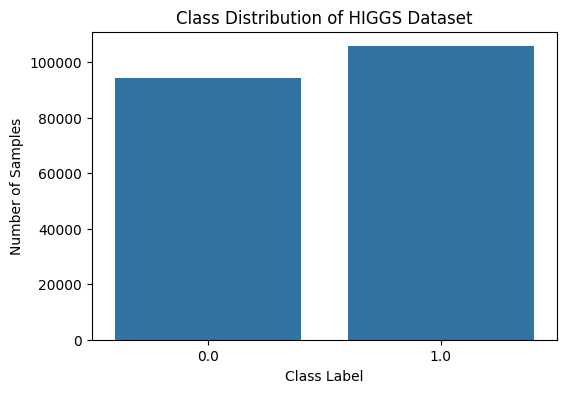

Class Counts:
label
1.0    105676
0.0     94324
Name: count, dtype: int64

Class Percentage:
label
1.0    52.838
0.0    47.162
Name: proportion, dtype: float64

OBSERVATION:
The class distribution plot shows the number of samples in class 0 and class 1.
If both classes have similar percentages, the dataset is balanced.
If one class is much higher than the other, the dataset is imbalanced.

In this sample, the percentages above show whether signal and background events are nearly balanced.



In [ ]:
# 6. Class distribution

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=data)
plt.title("Class Distribution of HIGGS Dataset")
plt.xlabel("Class Label")
plt.ylabel("Number of Samples")
plt.show()

class_counts = data['label'].value_counts()
class_percent = data['label'].value_counts(normalize=True) * 100

print("Class Counts:")
print(class_counts)

print("\nClass Percentage:")
print(class_percent)

print("""
OBSERVATION:
The class distribution plot shows the number of samples in class 0 and class 1.
If both classes have similar percentages, the dataset is balanced.
If one class is much higher than the other, the dataset is imbalanced.

In this sample, the percentages above show whether signal and background events are nearly balanced.
""")

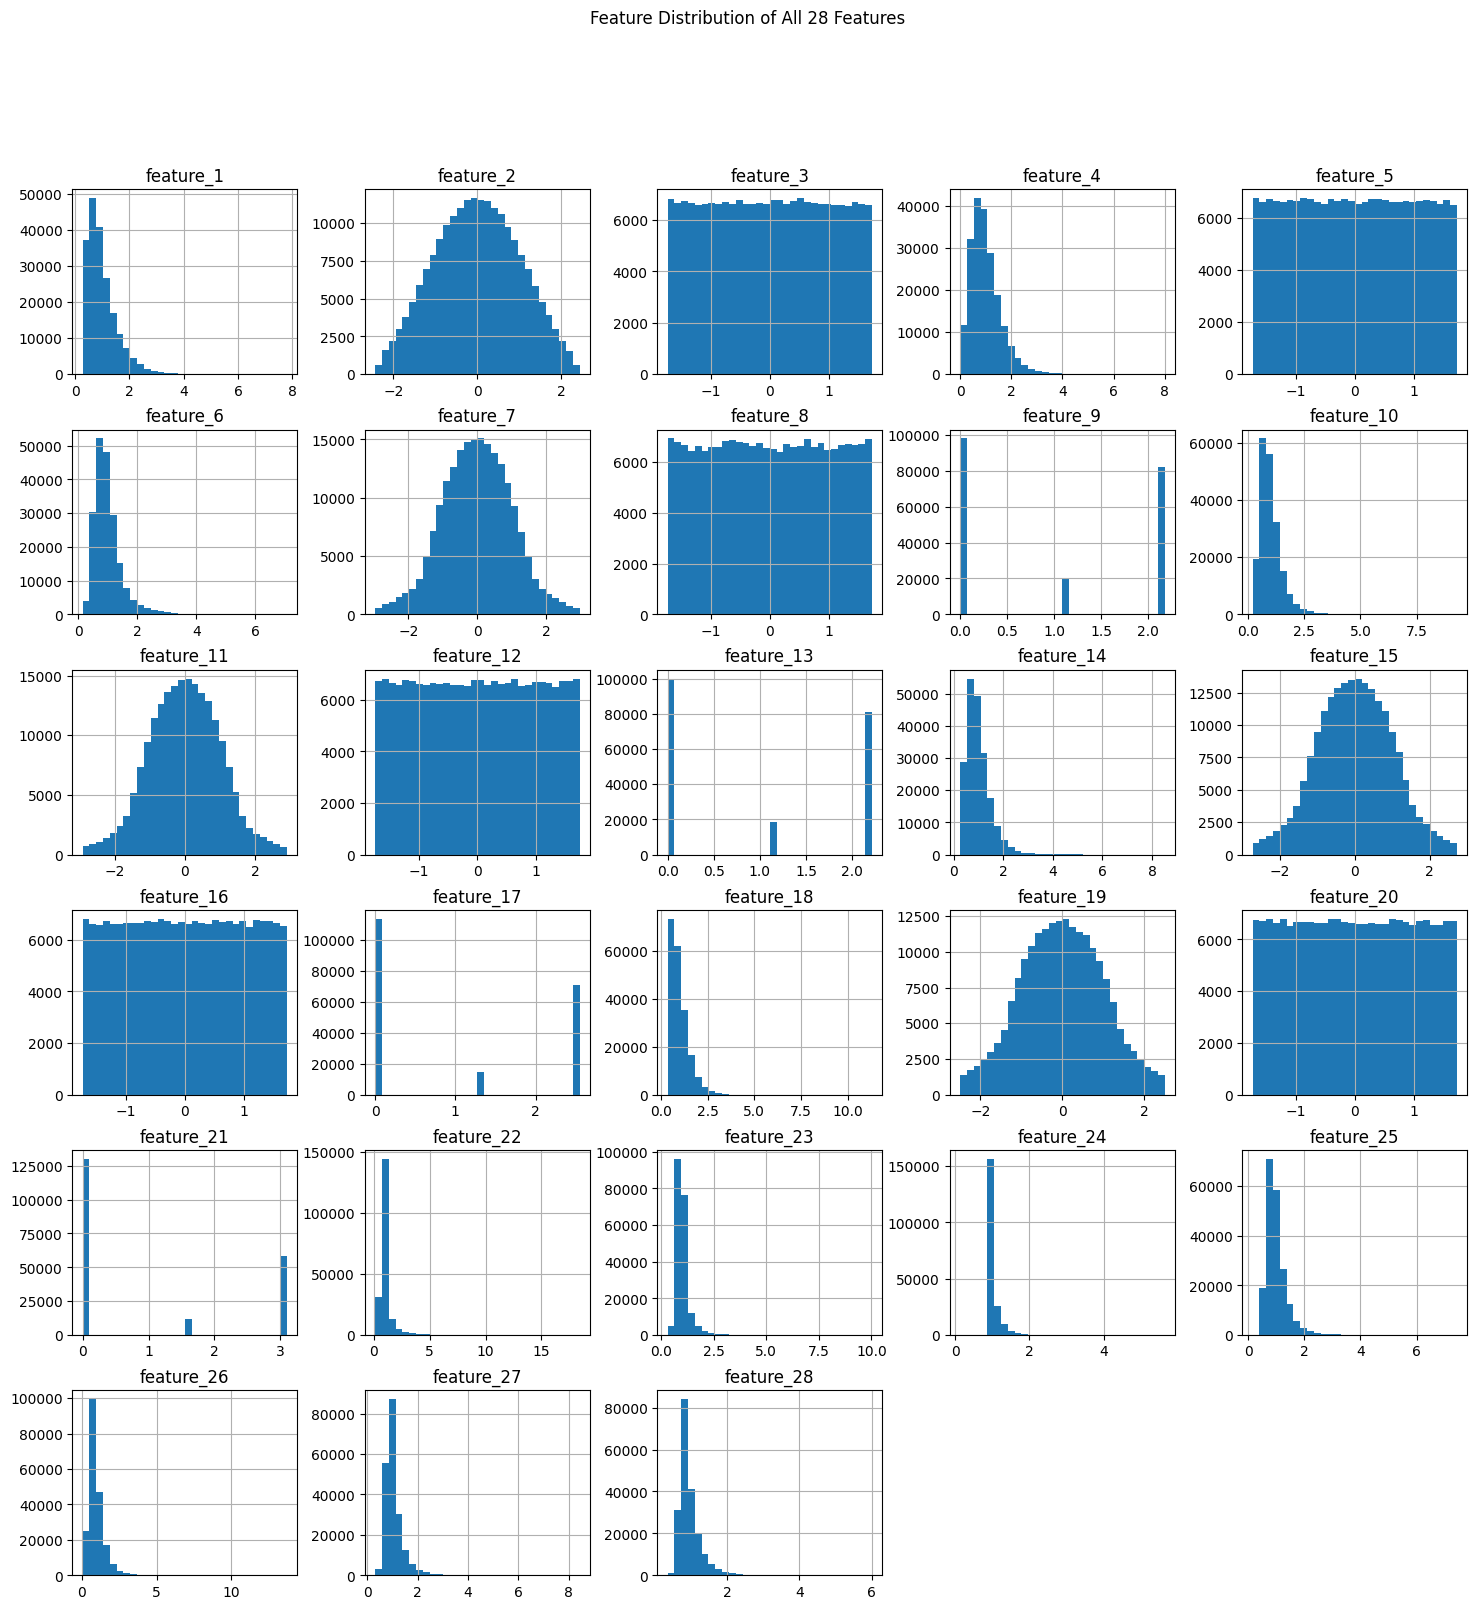


OBSERVATION:
The histograms show the distribution of all 28 numerical features.
Some features may be normally distributed, while others may be skewed.
Wide spread indicates high variation in feature values.
Long tails indicate possible outliers.
These observations show that feature scaling is needed for Logistic Regression and Linear SVM.



In [ ]:
# 7. Histograms for feature distribution

data.drop('label', axis=1).hist(figsize=(18,18), bins=30)
plt.suptitle("Feature Distribution of All 28 Features")
plt.show()

print("""
OBSERVATION:
The histograms show the distribution of all 28 numerical features.
Some features may be normally distributed, while others may be skewed.
Wide spread indicates high variation in feature values.
Long tails indicate possible outliers.
These observations show that feature scaling is needed for Logistic Regression and Linear SVM.
""")

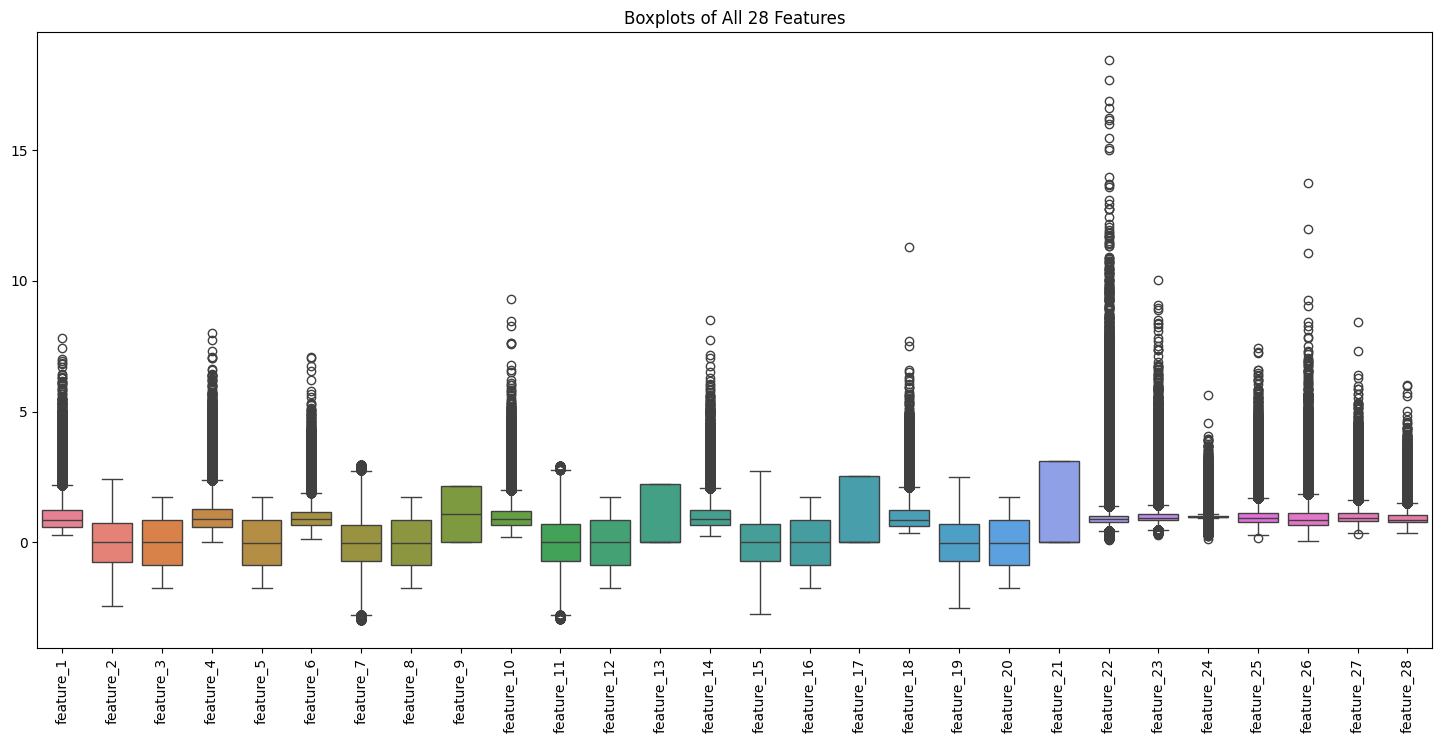


OBSERVATION:
The boxplots show the spread of each feature and possible outliers.
Points far away from the box represent outliers.
Since HIGGS is a physics dataset, extreme values may be meaningful and should not be removed directly.
Therefore, the values are kept and scaling is applied where required.



In [ ]:
# 8. Boxplots for outlier detection

plt.figure(figsize=(18,8))
sns.boxplot(data=data.drop('label', axis=1))
plt.xticks(rotation=90)
plt.title("Boxplots of All 28 Features")
plt.show()

print("""
OBSERVATION:
The boxplots show the spread of each feature and possible outliers.
Points far away from the box represent outliers.
Since HIGGS is a physics dataset, extreme values may be meaningful and should not be removed directly.
Therefore, the values are kept and scaling is applied where required.
""")

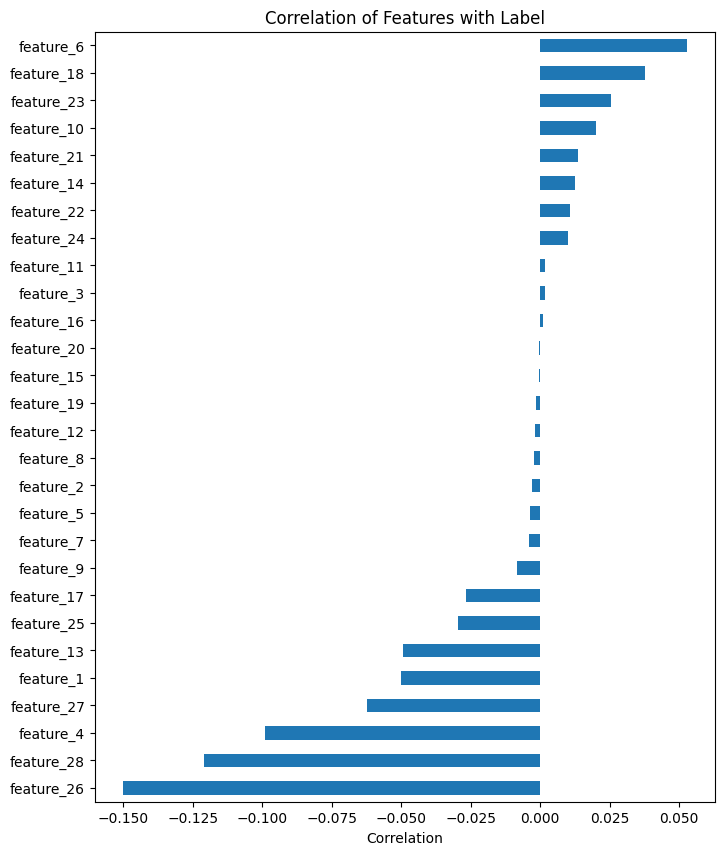

In [ ]:
plt.figure(figsize=(8,10))

label_corr = data.corr()['label'].drop('label')

label_corr.sort_values().plot(kind='barh')

plt.title("Correlation of Features with Label")
plt.xlabel("Correlation")
plt.show()

In [ ]:
# 10. Consistent train-test split

X = data.drop('label', axis=1)
y = data['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)

print("""
TRAIN-TEST SPLIT EXPLANATION:
A consistent 70:30 train-test split is used for all models.
The same training and testing data are used for Logistic Regression, Random Forest, and Linear SVM.
This makes the model comparison fair.
stratify=y is used to maintain the same class distribution in training and testing data.
""")

Training set: (140000, 28)
Testing set: (60000, 28)

TRAIN-TEST SPLIT EXPLANATION:
A consistent 70:30 train-test split is used for all models.
The same training and testing data are used for Logistic Regression, Random Forest, and Linear SVM.
This makes the model comparison fair.
stratify=y is used to maintain the same class distribution in training and testing data.



In [ ]:
# 11. Feature scaling

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("""
PREPROCESSING EXPLANATION:
StandardScaler is used to scale the features.
Logistic Regression and Linear SVM are distance/gradient-based models, so they need scaled data.
Random Forest does not require scaling because it is a tree-based model.
Therefore:
- Scaled data is used for Logistic Regression and Linear SVM.
- Original data is used for Random Forest.
""")


PREPROCESSING EXPLANATION:
StandardScaler is used to scale the features.
Logistic Regression and Linear SVM are distance/gradient-based models, so they need scaled data.
Random Forest does not require scaling because it is a tree-based model.
Therefore:
- Scaled data is used for Logistic Regression and Linear SVM.
- Original data is used for Random Forest.



In [ ]:
# 12. Logistic Regression

lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train_scaled, y_train)
lr_pred = lr_model.predict(X_test_scaled)

print("LOGISTIC REGRESSION RESULTS")
print("Accuracy:", accuracy_score(y_test, lr_pred))
print(classification_report(y_test, lr_pred))

print("""
INTERPRETATION:
Logistic Regression is used as a baseline model.
It performs well when the relationship between input features and output class is approximately linear.
If its accuracy is lower than Random Forest, it means the dataset may contain non-linear relationships.
""")

LOGISTIC REGRESSION RESULTS
Accuracy: 0.6405333333333333
              precision    recall  f1-score   support

         0.0       0.64      0.53      0.58     28297
         1.0       0.64      0.74      0.68     31703

    accuracy                           0.64     60000
   macro avg       0.64      0.63      0.63     60000
weighted avg       0.64      0.64      0.64     60000


INTERPRETATION:
Logistic Regression is used as a baseline model.
It performs well when the relationship between input features and output class is approximately linear.
If its accuracy is lower than Random Forest, it means the dataset may contain non-linear relationships.



In [ ]:
# 13. Random Forest with justified parameters

rf_model = RandomForestClassifier(
    n_estimators=50,
    max_depth=10,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_pred = rf_model.predict(X_test)

print("RANDOM FOREST RESULTS")
print("Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

print("""
PARAMETER JUSTIFICATION:
n_estimators=50 means 50 decision trees are used.
This gives better stability than a single decision tree while keeping training time reasonable in Colab.
max_depth=10 limits tree depth and reduces overfitting.
random_state=42 ensures reproducible results.
n_jobs=-1 uses all available CPU cores for faster training.
""")

RANDOM FOREST RESULTS
Accuracy: 0.7072333333333334
              precision    recall  f1-score   support

         0.0       0.70      0.66      0.68     28297
         1.0       0.71      0.75      0.73     31703

    accuracy                           0.71     60000
   macro avg       0.71      0.70      0.70     60000
weighted avg       0.71      0.71      0.71     60000


PARAMETER JUSTIFICATION:
n_estimators=50 means 50 decision trees are used.
This gives better stability than a single decision tree while keeping training time reasonable in Colab.
max_depth=10 limits tree depth and reduces overfitting.
random_state=42 ensures reproducible results.
n_jobs=-1 uses all available CPU cores for faster training.



In [ ]:
# 14. Linear SVM

svm_model = LinearSVC(
    C=1.0,
    max_iter=5000,
    random_state=42
)

svm_model.fit(X_train_scaled, y_train)
svm_pred = svm_model.predict(X_test_scaled)

print("LINEAR SVM RESULTS")
print("Accuracy:", accuracy_score(y_test, svm_pred))
print(classification_report(y_test, svm_pred))

print("""
INTERPRETATION:
Linear SVM tries to find the best separating hyperplane between class 0 and class 1.
It works well for high-dimensional numerical data.
If Linear SVM performs lower than Random Forest, it suggests that the HIGGS dataset has non-linear patterns.
""")

LINEAR SVM RESULTS
Accuracy: 0.6401333333333333
              precision    recall  f1-score   support

         0.0       0.65      0.52      0.58     28297
         1.0       0.64      0.75      0.69     31703

    accuracy                           0.64     60000
   macro avg       0.64      0.63      0.63     60000
weighted avg       0.64      0.64      0.63     60000


INTERPRETATION:
Linear SVM tries to find the best separating hyperplane between class 0 and class 1.
It works well for high-dimensional numerical data.
If Linear SVM performs lower than Random Forest, it suggests that the HIGGS dataset has non-linear patterns.



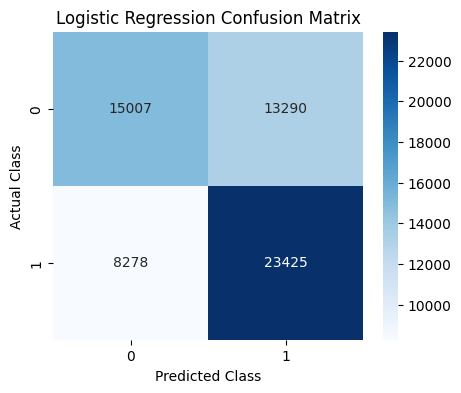

Logistic Regression
[[15007 13290]
 [ 8278 23425]]

INTERPRETATION:
The confusion matrix shows correct and incorrect predictions.
True positives and true negatives are correct predictions.
False positives and false negatives are incorrect predictions.
A better model has higher values on the diagonal and lower values outside the diagonal.



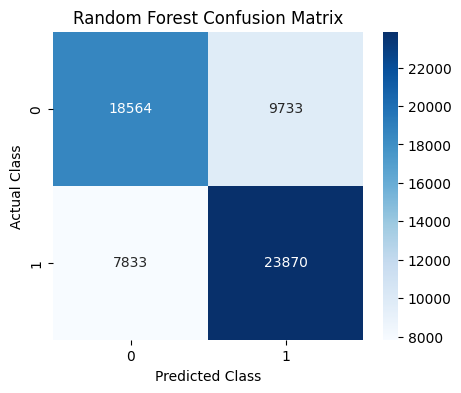

Random Forest
[[18564  9733]
 [ 7833 23870]]

INTERPRETATION:
The confusion matrix shows correct and incorrect predictions.
True positives and true negatives are correct predictions.
False positives and false negatives are incorrect predictions.
A better model has higher values on the diagonal and lower values outside the diagonal.



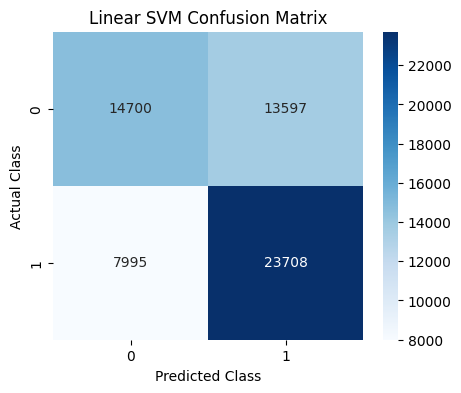

Linear SVM
[[14700 13597]
 [ 7995 23708]]

INTERPRETATION:
The confusion matrix shows correct and incorrect predictions.
True positives and true negatives are correct predictions.
False positives and false negatives are incorrect predictions.
A better model has higher values on the diagonal and lower values outside the diagonal.



In [ ]:
# 15. Confusion matrix for all models

models = {
    "Logistic Regression": lr_pred,
    "Random Forest": rf_pred,
    "Linear SVM": svm_pred
}

for model_name, predictions in models.items():
    cm = confusion_matrix(y_test, predictions)

    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(model_name + " Confusion Matrix")
    plt.xlabel("Predicted Class")
    plt.ylabel("Actual Class")
    plt.show()

    print(model_name)
    print(cm)
    print("""
INTERPRETATION:
The confusion matrix shows correct and incorrect predictions.
True positives and true negatives are correct predictions.
False positives and false negatives are incorrect predictions.
A better model has higher values on the diagonal and lower values outside the diagonal.
""")

,Model,Accuracy
0,Logistic Regression,0.640533
1,Random Forest,0.707233
2,Linear SVM,0.640133


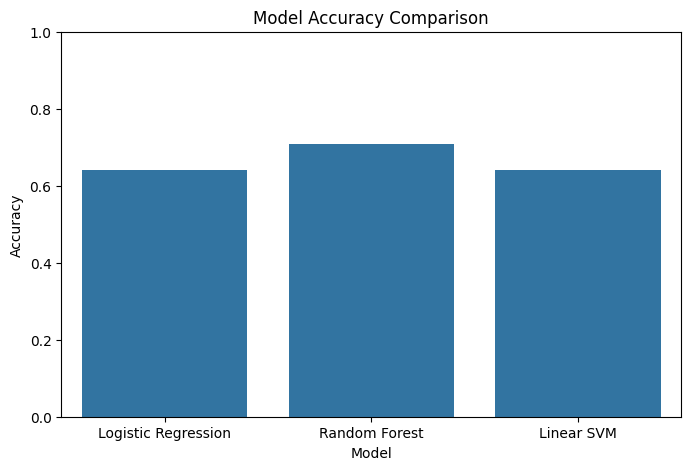


COMPARATIVE ANALYSIS:
All models are trained and tested on the same data split, so the comparison is fair.
Logistic Regression and Linear SVM are linear models.
Random Forest is a non-linear ensemble model.

If Random Forest gives the highest accuracy, it means it is better at capturing complex and non-linear relationships in the HIGGS dataset.

Best model based on accuracy:
Model       Random Forest
Accuracy         0.707233
Name: 1, dtype: object


In [ ]:
# 16. Model comparison table

results = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

display(results)

plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Model Accuracy Comparison")
plt.ylim(0,1)
plt.show()

best_model = results.sort_values(by="Accuracy", ascending=False).iloc[0]

print("""
COMPARATIVE ANALYSIS:
All models are trained and tested on the same data split, so the comparison is fair.
Logistic Regression and Linear SVM are linear models.
Random Forest is a non-linear ensemble model.

If Random Forest gives the highest accuracy, it means it is better at capturing complex and non-linear relationships in the HIGGS dataset.
""")

print("Best model based on accuracy:")
print(best_model)

,Feature,Importance
25,feature_26,0.248028
27,feature_28,0.128459
26,feature_27,0.116876
22,feature_23,0.086036
5,feature_6,0.074451
24,feature_25,0.072744
0,feature_1,0.038881
3,feature_4,0.037696
9,feature_10,0.031662
21,feature_22,0.026963


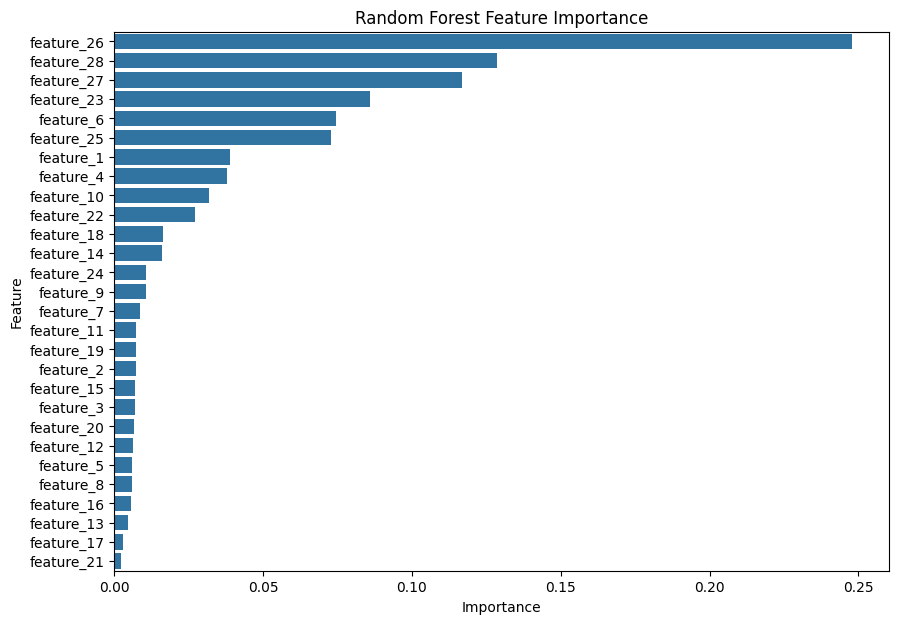


FEATURE IMPORTANCE INTERPRETATION:
Random Forest provides feature importance values.
Higher importance means the feature contributes more to classification.
The most important features help the model distinguish between signal and background events.
This analysis improves understanding of which features influence the model output.



In [ ]:
# 18. Random Forest feature importance

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
}).sort_values(by="Importance", ascending=False)

display(feature_importance)

plt.figure(figsize=(10,7))
sns.barplot(x="Importance", y="Feature", data=feature_importance)
plt.title("Random Forest Feature Importance")
plt.show()

print("""
FEATURE IMPORTANCE INTERPRETATION:
Random Forest provides feature importance values.
Higher importance means the feature contributes more to classification.
The most important features help the model distinguish between signal and background events.
This analysis improves understanding of which features influence the model output.
""")

In [ ]:
# 19. Hyperparameter tuning for Random Forest

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [10, 15]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=3,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Cross Validation Accuracy:", grid_search.best_score_)

best_rf = grid_search.best_estimator_
best_rf_pred = best_rf.predict(X_test)

print("Tuned Random Forest Test Accuracy:", accuracy_score(y_test, best_rf_pred))
print(classification_report(y_test, best_rf_pred))

print("""
HYPERPARAMETER TUNING EXPLANATION:
GridSearchCV is used to test different combinations of n_estimators and max_depth.
The best parameters are selected based on cross-validation accuracy.
This improves the reliability of the Random Forest model.
""")

Best Parameters: {'max_depth': 15, 'n_estimators': 100}
Best Cross Validation Accuracy: 0.718342858338615
Tuned Random Forest Test Accuracy: 0.7185166666666667
              precision    recall  f1-score   support

         0.0       0.71      0.69      0.70     28297
         1.0       0.73      0.75      0.74     31703

    accuracy                           0.72     60000
   macro avg       0.72      0.72      0.72     60000
weighted avg       0.72      0.72      0.72     60000


HYPERPARAMETER TUNING EXPLANATION:
GridSearchCV is used to test different combinations of n_estimators and max_depth.
The best parameters are selected based on cross-validation accuracy.
This improves the reliability of the Random Forest model.



In [ ]:
# 20. Final conclusion

print("""
FINAL CONCLUSION:

The HIGGS dataset classification problem is a binary classification task where the aim is to classify particle collision events as signal or background.

EDA showed the class distribution, feature distributions, correlation between features, and possible outliers.
The same 70:30 train-test split was used for all models to ensure fair comparison.
Feature scaling was applied for Logistic Regression and Linear SVM.

Logistic Regression and Linear SVM are linear models, while Random Forest is a non-linear ensemble model.
Random Forest generally performs better because it combines multiple decision trees and captures complex feature interactions.

Based on accuracy, classification report, confusion matrix, and feature importance, Random Forest is selected as the best model for this dataset.
""")


FINAL CONCLUSION:

The HIGGS dataset classification problem is a binary classification task where the aim is to classify particle collision events as signal or background.

EDA showed the class distribution, feature distributions, correlation between features, and possible outliers.
The same 70:30 train-test split was used for all models to ensure fair comparison.
Feature scaling was applied for Logistic Regression and Linear SVM.

Logistic Regression and Linear SVM are linear models, while Random Forest is a non-linear ensemble model.
Random Forest generally performs better because it combines multiple decision trees and captures complex feature interactions.

Based on accuracy, classification report, confusion matrix, and feature importance, Random Forest is selected as the best model for this dataset.



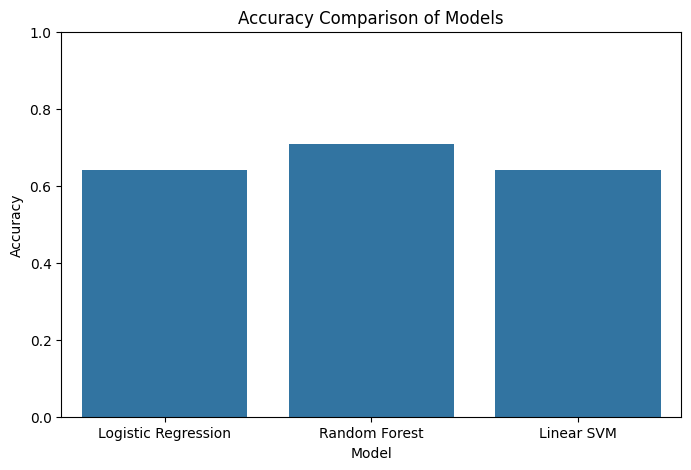

In [ ]:
results = pd.DataFrame({
    'Model':['Logistic Regression','Random Forest','Linear SVM'],
    'Accuracy':[
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ]
})

plt.figure(figsize=(8,5))
sns.barplot(x='Model', y='Accuracy', data=results)

plt.title("Accuracy Comparison of Models")
plt.ylim(0,1)

plt.show()

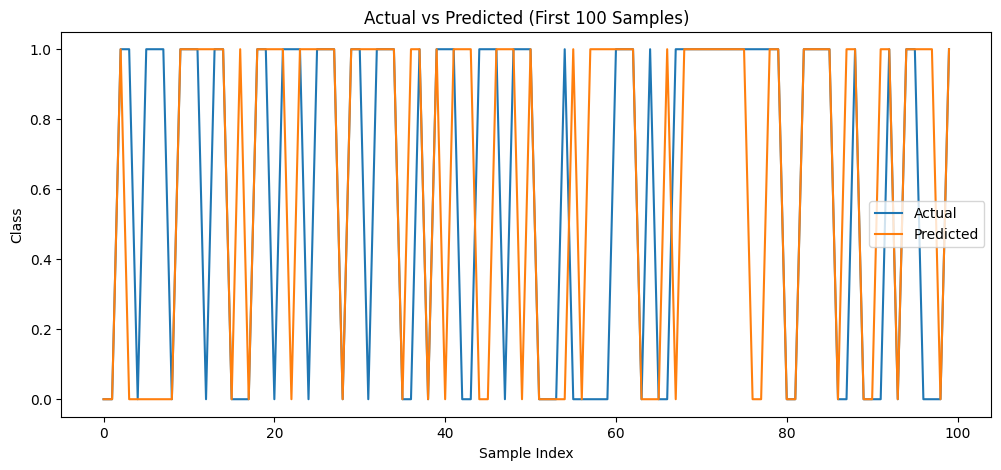

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(y_test.values[:100], label='Actual')
plt.plot(svm_pred[:100], label='Predicted')

plt.title("Actual vs Predicted (First 100 Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Class")

plt.legend()
plt.show()

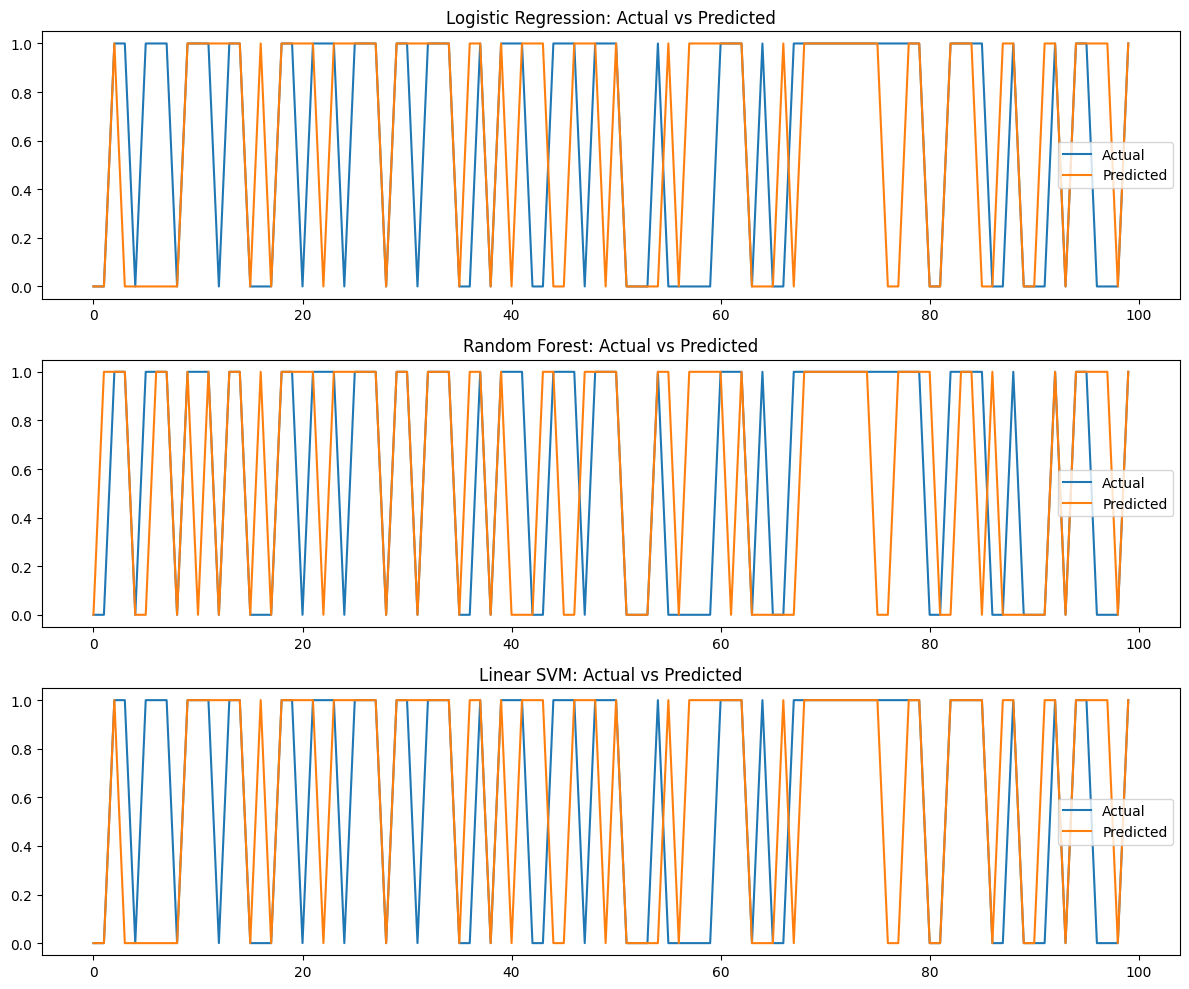

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(12,10))

n = 100

# Logistic Regression
axes[0].plot(y_test.values[:n], label='Actual')
axes[0].plot(lr_pred[:n], label='Predicted')
axes[0].set_title('Logistic Regression: Actual vs Predicted')
axes[0].legend()

# Random Forest
axes[1].plot(y_test.values[:n], label='Actual')
axes[1].plot(rf_pred[:n], label='Predicted')
axes[1].set_title('Random Forest: Actual vs Predicted')
axes[1].legend()

# Linear SVM
axes[2].plot(y_test.values[:n], label='Actual')
axes[2].plot(svm_pred[:n], label='Predicted')
axes[2].set_title('Linear SVM: Actual vs Predicted')
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
corr_matrix = data.corr()

print(corr_matrix['label'].sort_values(ascending=False))

label         1.000000
feature_6     0.052671
feature_18    0.037545
feature_23    0.025416
feature_10    0.020047
feature_21    0.013507
feature_14    0.012635
feature_22    0.010814
feature_24    0.009886
feature_11    0.001712
feature_3     0.001544
feature_16    0.000916
feature_20   -0.000303
feature_15   -0.000538
feature_19   -0.001442
feature_12   -0.001849
feature_8    -0.002425
feature_2    -0.002836
feature_5    -0.003803
feature_7    -0.003923
feature_9    -0.008500
feature_17   -0.026845
feature_25   -0.029588
feature_13   -0.049340
feature_1    -0.050114
feature_27   -0.062287
feature_4    -0.099171
feature_28   -0.121075
feature_26   -0.150082
Name: label, dtype: float64
